> **Note:** If you have opened this notebook before, Colab may show a cached version. To get the latest, go to **File → Open notebook → GitHub**, search for `anwai98/prompt-to-plot`, and reopen it from there.

# LLM-Assisted Data Plotting with Gemini

This notebook teaches you how to use a Large Language Model (Gemini) to **generate plotting code from plain English descriptions**.

Instead of looking up matplotlib/seaborn/plotly syntax, you describe what you want and the LLM writes the code for you.

### What you'll learn
- How to connect to Gemini via the Google Generative AI SDK
- How to pass data context to an LLM so it understands your dataset
- How to generate and run plotting code for **matplotlib**, **seaborn**, and **plotly**
- How to write better prompts for more precise plots

### Prerequisites
- A free Gemini API key from [Google AI Studio](https://aistudio.google.com/app/apikey)
- Store your key in Colab Secrets (the key icon in the left sidebar) under the name `GEMINI_API_KEY`

## Install & Import Dependencies

In [1]:
!pip install -q -U google-genai

In [2]:
import re
import textwrap
import time

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

from google import genai
from google.genai import errors as genai_errors
from google.colab import userdata

GEMINI_API_KEY = userdata.get('GEMINI_API_KEY')
client = genai.Client(api_key=GEMINI_API_KEY)
MODEL = 'gemini-flash-lite-latest'

print('Setup complete. Gemini is ready.')

Setup complete. Gemini is ready.


## Dummy Datasets

We create three small datasets inline. In a real project you would load a CSV with `pd.read_csv()`.

| Dataset | Description | Good for |
|---|---|---|
| `df_sales` | Monthly sales by product category | bar charts, line charts |
| `df_students` | Exam scores, study hours, grade group | histograms, box plots, heatmaps |
| `df_countries` | GDP, population, life expectancy | scatter plots, bubble charts |

In [3]:
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
rng = np.random.default_rng(42)

df_sales = pd.DataFrame({
    'Month': months,
    'Electronics': rng.integers(15000, 35000, 12),
    'Clothing': rng.integers(8000, 20000, 12),
    'Groceries': rng.integers(20000, 40000, 12),
    'Furniture': rng.integers(5000, 15000, 12),
})
df_sales['Total'] = df_sales[['Electronics', 'Clothing', 'Groceries', 'Furniture']].sum(axis=1)

print('df_sales shape:', df_sales.shape)
df_sales.head()

df_sales shape: (12, 6)


,Month,Electronics,Clothing,Groceries,Furniture,Total
0,Jan,16785,16829,35631,13582,82827
1,Feb,30479,17133,32877,13276,93765
2,Mar,28091,16609,28048,7767,80515
3,Apr,23777,17432,36455,11316,88980
4,May,23660,14158,30908,6652,75378


In [4]:
n = 120
df_students = pd.DataFrame({
    'student_id': range(1, n + 1),
    'exam_score': np.clip(rng.normal(65, 15, n), 0, 100).round(1),
    'study_hours': np.clip(rng.normal(6, 2.5, n), 0, 15).round(1),
    'assignments': np.clip(rng.normal(75, 12, n), 0, 100).round(1),
    'attendance': np.clip(rng.normal(80, 10, n), 0, 100).round(1),
    'grade_group': rng.choice(['A', 'B', 'C', 'D'], n, p=[0.2, 0.35, 0.3, 0.15]),
})

print('df_students shape:', df_students.shape)
df_students.head()

df_students shape: (120, 6)


,student_id,exam_score,study_hours,assignments,attendance,grade_group
0,1,58.6,4.0,80.7,64.0,B
1,2,59.7,5.0,87.2,72.1,D
2,3,73.0,4.5,76.9,84.4,D
3,4,70.5,5.6,79.2,85.2,C
4,5,71.2,8.7,75.6,82.8,B


In [5]:
country_names = [f'Country_{i}' for i in range(1, 51)]
continents = rng.choice(
    ['Africa', 'Asia', 'Europe', 'Americas', 'Oceania'],
    50,
    p=[0.25, 0.3, 0.25, 0.15, 0.05]
)

df_countries = pd.DataFrame({
    'country': country_names,
    'continent': continents,
    'gdp_per_capita': np.clip(rng.lognormal(9, 1.2, 50), 500, 80000).round(),
    'life_expectancy': np.clip(rng.normal(70, 10, 50), 45, 85).round(1),
    'population_M': np.clip(rng.lognormal(3, 1.5, 50), 0.5, 1400).round(1),
    'co2_per_capita': np.clip(rng.lognormal(1.5, 0.8, 50), 0.1, 20).round(2),
})

print('df_countries shape:', df_countries.shape)
df_countries.head()

df_countries shape: (50, 6)


,country,continent,gdp_per_capita,life_expectancy,population_M,co2_per_capita
0,Country_1,Americas,4327.0,66.5,2.9,5.58
1,Country_2,Africa,500.0,59.8,250.3,1.80
2,Country_3,Asia,20781.0,69.0,268.7,3.05
3,Country_4,Europe,11236.0,81.3,154.3,14.16
4,Country_5,Africa,3440.0,47.2,29.5,1.77


## Helper Functions

Two functions power the notebook:

1. **`build_prompt`** — Describes your DataFrame to Gemini (column names, types, sample rows) plus your request, and instructs the model to return only runnable Python code.
2. **`ask_gemini_to_plot`** — Calls the Gemini API, extracts the code block from the response, and executes it.

In [6]:
def build_prompt(df, df_name, user_request, library_hint=''):
    col_info = ', '.join(
        [f'{col} ({dtype})' for col, dtype in zip(df.columns, df.dtypes)]
    )
    sample_rows = df.head(3).to_string(index=False)
    library_line = f'Use the {library_hint} library.' if library_hint else ''

    return textwrap.dedent(f"""
        You are a Python data visualisation expert.
        A pandas DataFrame called `{df_name}` is already defined with these columns:
          {col_info}

        First 3 rows:
        {sample_rows}

        Task: {user_request}
        {library_line}

        Rules:
        - Return ONLY a Python code block (```python ... ```).
        - Do NOT include any explanation or text outside the code block.
        - The DataFrame `{df_name}` is already loaded — do not reload or redefine it.
        - All required libraries (matplotlib, seaborn, plotly, pandas, numpy) are already imported.
        - End matplotlib/seaborn plots with `plt.tight_layout(); plt.show()`.
        - End plotly plots with `fig.show()`.
    """).strip()


def build_fix_prompt(code, error):
    return textwrap.dedent(f"""
        The following Python plotting code raised an error when executed:

        ```python
        {code}
        ```

        Error:
        {error}

        Fix the code so it runs without errors. Return ONLY the corrected Python code block.
    """).strip()


def extract_code(text):
    match = re.search(r'```(?:python)?\n(.*?)```', text, re.DOTALL)
    return match.group(1).strip() if match else text.strip()


def parse_retry_wait(exc, default=60):
    match = re.search(r'retry in (\d+(?:\.\d+)?)s', str(exc))
    return int(float(match.group(1))) + 5 if match else default


def call_gemini(prompt):
    for attempt in range(5):
        try:
            response = client.models.generate_content(model=MODEL, contents=prompt)
            return response
        except genai_errors.ClientError as e:
            if '429' in str(e) or 'quota' in str(e).lower():
                wait = parse_retry_wait(e)
                print(f'Rate limit hit, waiting {wait}s before retry {attempt + 1}/5...')
                time.sleep(wait)
            else:
                raise
        except genai_errors.ServerError:
            print(f'Service unavailable, retrying {attempt + 1}/5...')
            time.sleep(5)
    return None


def ask_gemini_to_plot(df, df_name, user_request, library_hint='', print_code=True):
    prompt = build_prompt(df, df_name, user_request, library_hint)
    response = call_gemini(prompt)

    if response is None:
        print('Failed to get a response after 5 attempts.')
        return

    code = extract_code(response.text)

    if print_code:
        print(code)

    exec_globals = {
        df_name: df,
        'pd': pd,
        'np': np,
        'plt': plt,
        'matplotlib': matplotlib,
        'sns': sns,
        'px': px,
        'go': go,
    }

    try:
        exec(code, exec_globals)  # noqa: S102
    except Exception as e:
        print(f'Execution error: {e}. Asking Gemini to fix...')
        plt.close('all')
        fix_response = call_gemini(build_fix_prompt(code, e))
        if fix_response is None:
            print('Failed to get a fix.')
            return
        fixed_code = extract_code(fix_response.text)
        if print_code:
            print('Fixed code:')
            print(fixed_code)
        exec(fixed_code, exec_globals)  # noqa: S102

## Matplotlib Examples

Matplotlib is the most widely used Python plotting library — it gives you full control over every detail of a static figure.

**Example 1:** Ask Gemini to generate a grouped bar chart showing monthly sales broken down by product category.

import matplotlib.pyplot as plt
import numpy as np

# Set the positions and width for the bars
categories = ['Electronics', 'Clothing', 'Groceries', 'Furniture']
x = np.arange(len(df_sales['Month']))
width = 0.2

fig, ax = plt.subplots(figsize=(10, 6))

# Plot each category as a grouped bar
for i, category in enumerate(categories):
    ax.bar(x + (i - 1.5) * width, df_sales[category], width, label=category)

# Customize the chart
ax.set_ylabel('Sales')
ax.set_xlabel('Month')
ax.set_title('Monthly Sales by Product Category')
ax.set_xticks(x)
ax.set_xticklabels(df_sales['Month'])
ax.legend()

plt.tight_layout()
plt.show()


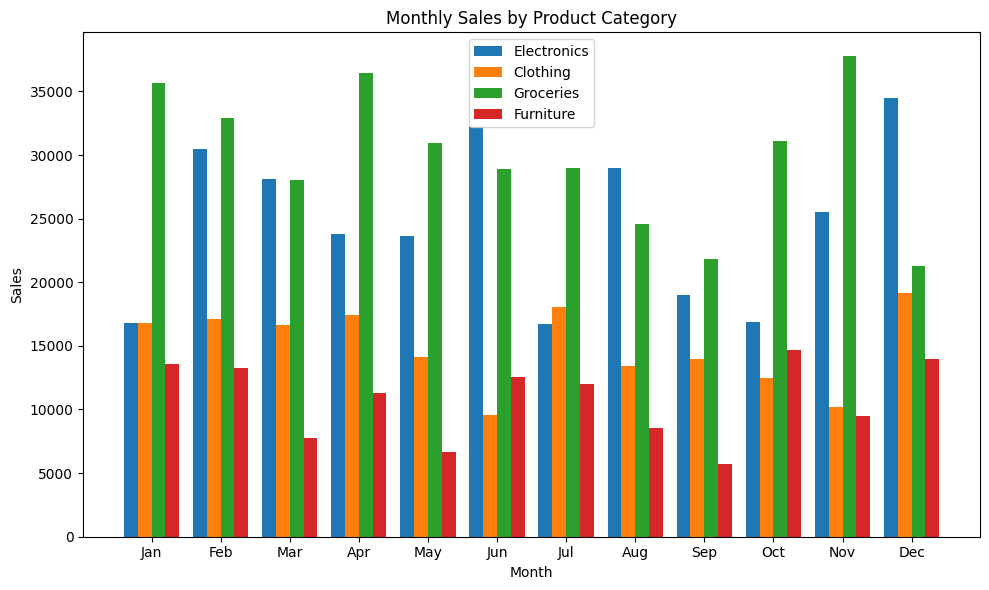

In [7]:
ask_gemini_to_plot(
    df=df_sales,
    df_name='df_sales',
    user_request=(
        'Create a grouped bar chart showing monthly sales for each product category '
        '(Electronics, Clothing, Groceries, Furniture). '
        'Use a distinct color per category. Add a legend, axis labels, and a title.'
    ),
    library_hint='matplotlib',
)

**Example 2:** Ask Gemini to plot total monthly sales as a line chart and annotate the peak month.

# Find the row with the maximum total sales
max_idx = df_sales['Total'].idxmax()
max_val = df_sales.loc[max_idx, 'Total']
max_month = df_sales.loc[max_idx, 'Month']

# Plot the data
plt.figure(figsize=(10, 6))
plt.plot(df_sales['Month'], df_sales['Total'], marker='o', linestyle='-', color='b', label='Total Sales')

# Mark the highest point
plt.plot(max_month, max_val, 'ro', markersize=10)
plt.annotate(f'{max_val}', xy=(max_month, max_val), xytext=(5, 5), textcoords='offset points')

# Add labels and title
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.title('Monthly Total Sales')

plt.tight_layout()
plt.show()


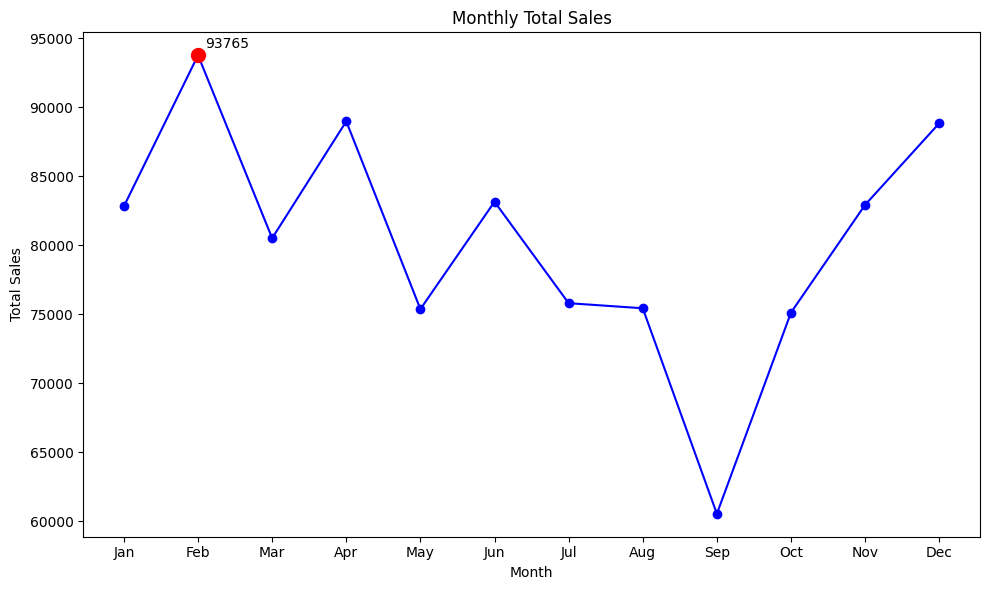

In [8]:
ask_gemini_to_plot(
    df=df_sales,
    df_name='df_sales',
    user_request=(
        'Plot the Total monthly sales as a line chart. '
        'Mark the month with the highest total sales with a red dot and annotate it '
        'with the exact value. Add axis labels and a title.'
    ),
    library_hint='matplotlib',
)

## Seaborn Examples

Seaborn is built on top of matplotlib and is designed for **statistical visualisation** — it makes it easy to show distributions, relationships, and group comparisons.

**Example 3:** Ask Gemini to plot the distribution of exam scores as a histogram with a KDE overlay and a mean line.

plt.figure(figsize=(10, 6))
sns.histplot(df_students['exam_score'], bins=20, kde=True, color='skyblue', stat='density')

mean_score = df_students['exam_score'].mean()
plt.axvline(mean_score, color='navy', linestyle='--', label=f'Mean: {mean_score:.2f}')

plt.title('Distribution of Exam Scores with KDE')
plt.xlabel('Exam Score')
plt.ylabel('Density')
plt.legend()

plt.tight_layout()
plt.show()


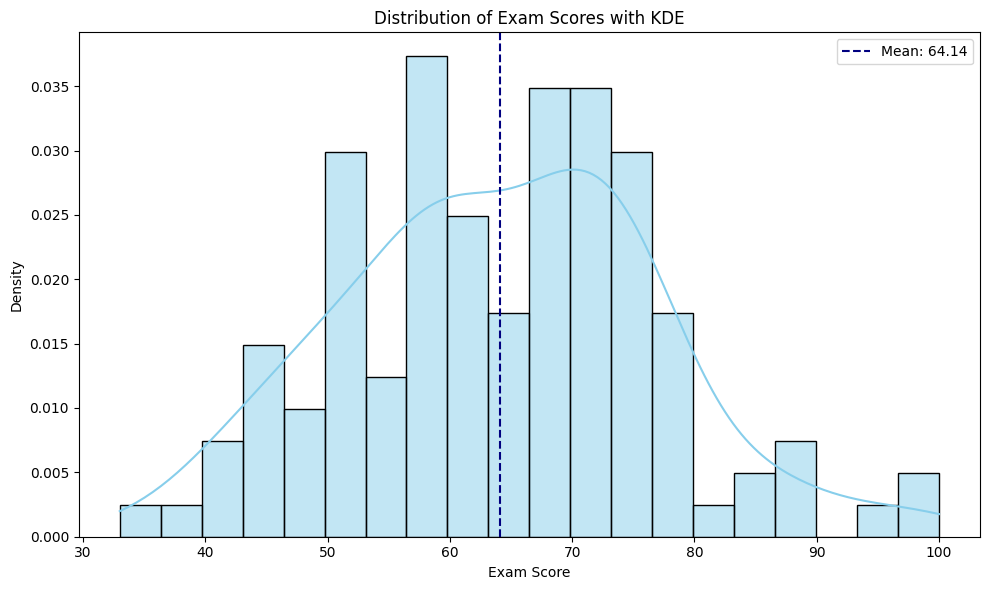

In [9]:
ask_gemini_to_plot(
    df=df_students,
    df_name='df_students',
    user_request=(
        'Plot a histogram of exam_score with a KDE (kernel density estimate) overlay. '
        'Use 20 bins and a soft blue color palette. Add a vertical dashed line at the mean score. '
        'Add axis labels and a title.'
    ),
    library_hint='seaborn',
)

**Example 4:** Ask Gemini to compare exam score distributions across grade groups using a box plot.

sns.boxplot(
    data=df_students,
    x='grade_group',
    y='exam_score',
    order=['A', 'B', 'C', 'D'],
    hue='grade_group',
    legend=False
)
plt.title('Distribution of Exam Scores by Grade Group')
plt.xlabel('Grade Group')
plt.ylabel('Exam Score')
plt.tight_layout()
plt.show()


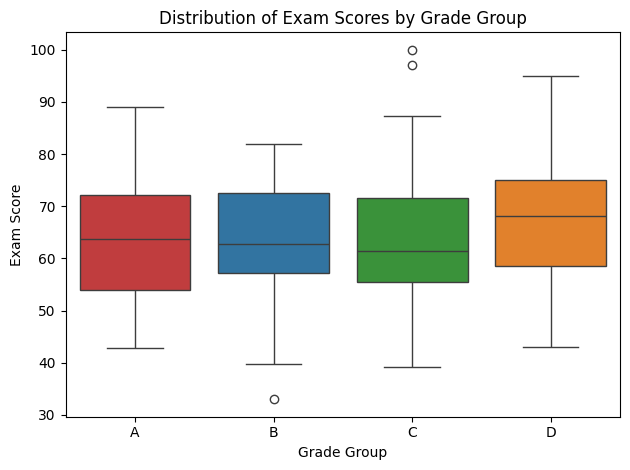

In [10]:
ask_gemini_to_plot(
    df=df_students,
    df_name='df_students',
    user_request=(
        'Create a box plot showing the distribution of exam_score for each grade_group '
        '(A, B, C, D). Order the groups from A to D on the x-axis. '
        'Color each group differently. Add axis labels and a title.'
    ),
    library_hint='seaborn',
)

**Example 5:** Ask Gemini to compute and visualise the correlation matrix of all numeric columns as a heatmap.

import matplotlib.pyplot as plt
import seaborn as sns

# Compute the correlation matrix for numeric columns
corr_matrix = df_students.select_dtypes(include=['number']).corr()

# Create the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix, 
    annot=True, 
    fmt=".2f", 
    cmap='vlag', 
    center=0, 
    vmin=-1, 
    vmax=1
)

plt.title('Correlation Matrix of Student Performance Metrics')
plt.tight_layout()
plt.show()


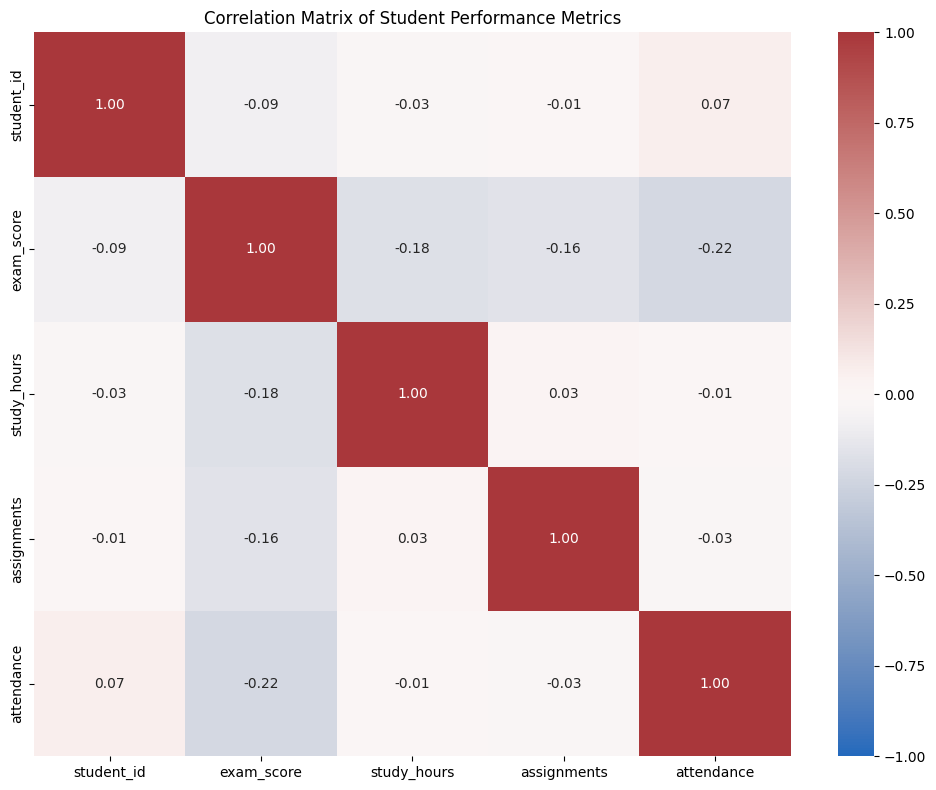

In [11]:
ask_gemini_to_plot(
    df=df_students,
    df_name='df_students',
    user_request=(
        'Compute the correlation matrix of all numeric columns and display it as a heatmap. '
        'Annotate each cell with the correlation value rounded to 2 decimal places. '
        'Use a diverging color palette centered at 0. Add a title.'
    ),
    library_hint='seaborn',
)

## Plotly Examples

Plotly produces **interactive** charts — you can hover for exact values, zoom in, pan, and toggle series on/off.

**Example 6:** Ask Gemini to create an interactive bubble chart of GDP vs life expectancy, with bubble size representing population.

In [12]:
ask_gemini_to_plot(
    df=df_countries,
    df_name='df_countries',
    user_request=(
        'Create an interactive scatter plot with gdp_per_capita on the x-axis (log scale) '
        'and life_expectancy on the y-axis. '
        'Size each bubble by population_M and color by continent. '
        'Add hover labels that show the country name, GDP, and life expectancy. '
        'Add axis labels and a title.'
    ),
    library_hint='plotly',
)

import plotly.express as px

fig = px.scatter(
    df_countries,
    x="gdp_per_capita",
    y="life_expectancy",
    size="population_M",
    color="continent",
    hover_name="country",
    hover_data={"gdp_per_capita": ":.2f", "life_expectancy": ":.2f"},
    log_x=True,
    title="GDP per Capita vs. Life Expectancy by Continent",
    labels={
        "gdp_per_capita": "GDP per Capita (USD)",
        "life_expectancy": "Life Expectancy (Years)",
        "population_M": "Population (Millions)",
        "continent": "Continent"
    }
)

fig.show()


**Example 7:** Ask Gemini to create an interactive stacked bar chart of monthly sales broken down by category.

In [13]:
ask_gemini_to_plot(
    df=df_sales,
    df_name='df_sales',
    user_request=(
        'Create an interactive stacked bar chart showing monthly sales broken down by '
        'Electronics, Clothing, Groceries, and Furniture. '
        'Show the Month on the x-axis. Add a legend, axis labels, and a title.'
    ),
    library_hint='plotly',
)

import plotly.express as px

fig = px.bar(
    df_sales,
    x='Month',
    y=['Electronics', 'Clothing', 'Groceries', 'Furniture'],
    title='Monthly Sales by Category',
    labels={'value': 'Sales Amount', 'variable': 'Category', 'Month': 'Month'},
    barmode='stack'
)

fig.update_layout(
    xaxis_title='Month',
    yaxis_title='Total Sales',
    legend_title='Categories'
)

fig.show()


## Biological Data: Gene Expression Examples

Gene expression data measures how active each gene is under different conditions. The two datasets below mimic what you'd get from an RNA-seq experiment comparing a treated sample against a control.

| Dataset | Description | Good for |
|---|---|---|
| `df_volcano` | 200 genes with fold change and p-value | volcano plots |
| `df_heatmap` | Top 20 genes x 6 samples (3 ctrl, 3 treated) | expression heatmaps |

In [14]:
n_genes = 200
gene_names = [f'GENE_{i:03d}' for i in range(1, n_genes + 1)]
log2fc = rng.normal(0, 1.5, n_genes)
pval = rng.uniform(0, 1, n_genes)

sig_mask = (np.abs(log2fc) > 1.5) & (pval < 0.05)
pval[sig_mask] = rng.uniform(0, 0.001, sig_mask.sum())

df_volcano = pd.DataFrame({
    'gene': gene_names,
    'log2fc': log2fc.round(3),
    'pval': pval.round(5),
    'neg_log10_pval': (-np.log10(pval + 1e-10)).round(3),
    'significant': (np.abs(log2fc) > 1) & (pval < 0.05),
})

print('df_volcano shape:', df_volcano.shape)
df_volcano.head()

samples = ['ctrl_1', 'ctrl_2', 'ctrl_3', 'treat_1', 'treat_2', 'treat_3']
top_genes = (
    df_volcano.nlargest(10, 'neg_log10_pval')['gene'].tolist()
    + df_volcano.nsmallest(10, 'log2fc')['gene'].tolist()
)
expr_data = rng.normal(0, 1, (20, 6))
expr_data[:10, 3:] += 2
expr_data[10:, 3:] -= 2

df_heatmap = pd.DataFrame(expr_data.round(2), index=top_genes, columns=samples)

print('df_heatmap shape:', df_heatmap.shape)
df_heatmap.head()

df_volcano shape: (200, 5)
df_heatmap shape: (20, 6)


,ctrl_1,ctrl_2,ctrl_3,treat_1,treat_2,treat_3
GENE_058,-0.84,0.66,0.65,2.59,3.54,3.45
GENE_055,-0.37,0.37,-0.62,2.02,1.40,3.62
GENE_118,0.36,-0.22,1.19,-0.17,-0.01,2.80
GENE_102,0.06,0.25,-1.33,1.98,4.00,2.82
GENE_158,0.17,-0.44,-0.39,-0.13,2.26,2.85


**Example 8:** Ask Gemini to create a volcano plot — a standard plot in genomics that shows which genes are statistically significant and strongly up/down-regulated.

import matplotlib.pyplot as plt

# Create the scatter plot
plt.figure(figsize=(10, 6))

# Define colors based on significance
colors = df_volcano['significant'].map({True: 'red', False: 'grey'})

# Plot the points
plt.scatter(df_volcano['log2fc'], df_volcano['neg_log10_pval'], c=colors, alpha=0.6, s=20)

# Add threshold lines
plt.axvline(x=1, color='black', linestyle='--', linewidth=1)
plt.axvline(x=-1, color='black', linestyle='--', linewidth=1)
plt.axhline(y=-np.log10(0.05), color='black', linestyle='--', linewidth=1)

# Label top 5 most significant genes
top_5 = df_volcano.nlargest(5, 'neg_log10_pval')
for i, row in top_5.iterrows():
    plt.text(row['log2fc'], row['neg_log10_pval'], row['gene'], fontsize=9)

# Labels and title
plt.xlabel('log2 Fold Change')
plt.ylabel('-log10(p-value)')
plt.title('Volcano Plot')

plt.tight_layout()
plt.show()


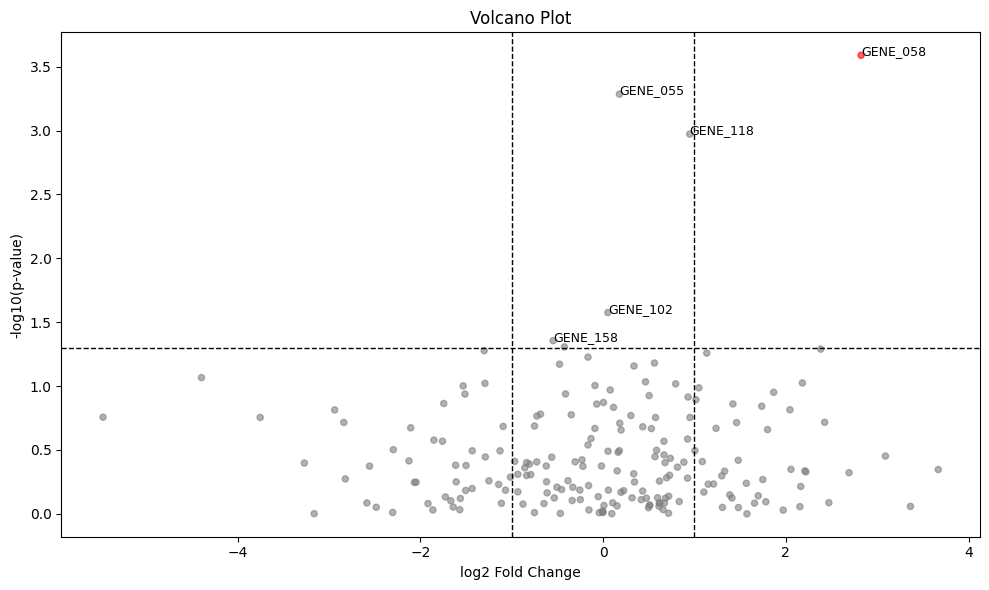

In [15]:
ask_gemini_to_plot(
    df=df_volcano,
    df_name='df_volcano',
    user_request=(
        'Create a volcano plot with log2fc on the x-axis and neg_log10_pval on the y-axis. '
        'Color points by the significant column: red for significant, grey for not significant. '
        'Add dashed threshold lines at x = -1 and x = 1, and at y = -log10(0.05). '
        'Label the top 5 most significant genes by name. Add axis labels and a title.'
    ),
    library_hint='matplotlib',
)

**Example 9:** Ask Gemini to create a gene expression heatmap showing the top differentially expressed genes across control and treated samples.

g = sns.clustermap(
    df_heatmap,
    cmap="RdBu_r",
    center=0,
    col_cluster=False,
    row_cluster=True,
    yticklabels=True,
    figsize=(8, 10)
)
g.fig.suptitle('Gene Expression Heatmap', y=1.02)
plt.tight_layout()
plt.show()


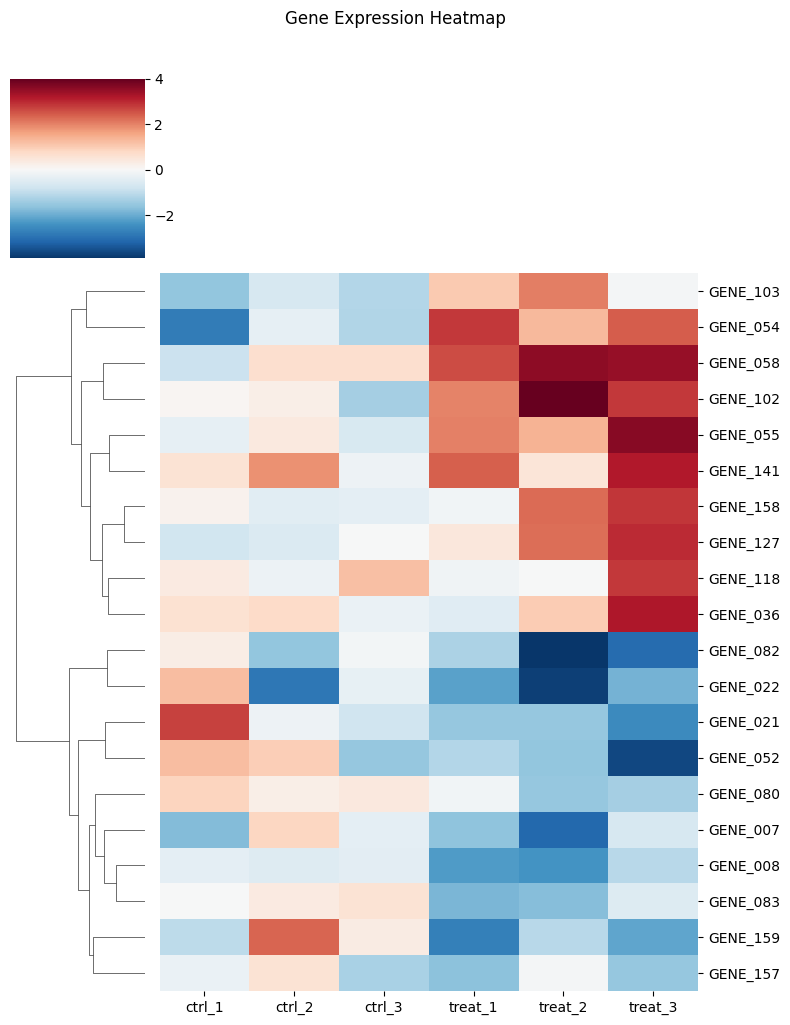

In [16]:
ask_gemini_to_plot(
    df=df_heatmap,
    df_name='df_heatmap',
    user_request=(
        'Create a clustered heatmap of the gene expression matrix. '
        'Rows are genes, columns are samples (ctrl_1-3 and treat_1-3). '
        'Use a red-blue diverging palette centered at 0. '
        'Add a title and make gene names readable on the y-axis.'
    ),
    library_hint='seaborn',
)

**Example 10:** Ask Gemini to create an interactive volcano plot so you can hover over individual genes to see their name, fold change, and p-value.

In [17]:
ask_gemini_to_plot(
    df=df_volcano,
    df_name='df_volcano',
    user_request=(
        'Create an interactive volcano plot with log2fc on the x-axis and neg_log10_pval on the y-axis. '
        'Color points by the significant column: red for significant, grey for not significant. '
        'Add hover tooltips showing the gene name, log2fc, and pval. '
        'Add dashed threshold lines at x = -1, x = 1, and y = -log10(0.05). '
        'Add axis labels and a title.'
    ),
    library_hint='plotly',
)

import plotly.express as px
import numpy as np

# Map the boolean significant column to colors
color_map = {True: 'red', False: 'grey'}

fig = px.scatter(
    df_volcano,
    x='log2fc',
    y='neg_log10_pval',
    color='significant',
    color_discrete_map=color_map,
    hover_data=['gene', 'log2fc', 'pval'],
    title='Volcano Plot',
    labels={
        'log2fc': 'log2 Fold Change',
        'neg_log10_pval': '-log10(p-value)',
        'significant': 'Significant'
    }
)

# Add threshold lines
fig.add_vline(x=-1, line_dash="dash", line_color="black")
fig.add_vline(x=1, line_dash="dash", line_color="black")
fig.add_hline(y=-np.log10(0.05), line_dash="dash", line_color="black")

# Update layout for cleaner look
fig.update_layout(
    template='plotly_white',
    showlegend=True
)

fig.show()


## Tips for Writing Better Prompts

| Vague prompt | Better prompt |
|---|---|
| "plot the sales" | "Create a bar chart of total monthly sales with months on the x-axis" |
| "show the distribution" | "Show a histogram of exam_score with 20 bins and a KDE overlay" |
| "scatter plot" | "Scatter plot: x = gdp_per_capita (log scale), y = life_expectancy, colored by continent" |

Useful things to include: which columns to use for x/y/color/size, which library, axis scaling, annotations, color preferences, and any data transformations.

## Your Turn

Edit the three variables below and run the cell.

In [ ]:
MY_DATASET = df_students          # choose: df_sales, df_students, df_countries
MY_DATASET_NAME = 'df_students'   # match the variable name above as a string
MY_LIBRARY = 'seaborn'            # choose: 'matplotlib', 'seaborn', 'plotly'
MY_REQUEST = """
Create a scatter plot of study_hours vs exam_score, colored by grade_group.
Add a linear regression trend line for each group.
Add axis labels and a title.
"""

ask_gemini_to_plot(
    df=MY_DATASET,
    df_name=MY_DATASET_NAME,
    user_request=MY_REQUEST,
    library_hint=MY_LIBRARY,
)